import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("loan_approval_data.csv")

In [16]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# handling missing values


In [18]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [20]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [48]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [57]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [59]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [61]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

Text(0.5, 1.0, 'approved or not')

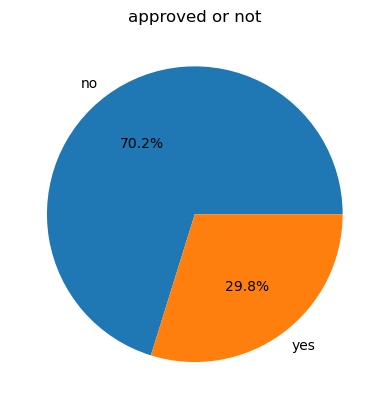

In [72]:
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count , labels=["no" , "yes"], autopct ="%1.1f%%")
plt.title("approved or not")

[Text(0, 0, '722'), Text(0, 0, '278')]

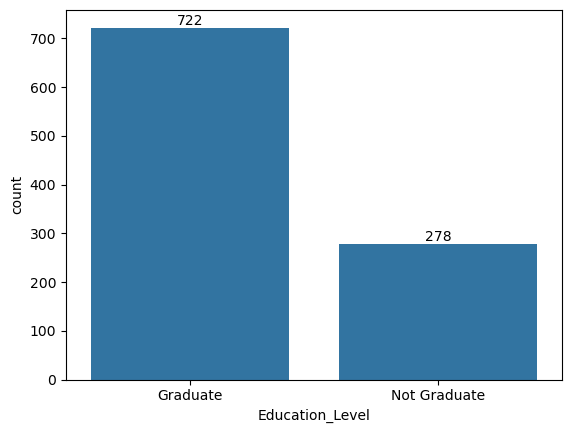

In [86]:
#analyze kisko loan mil raha hai aur kisko nahi
emp_status = df["Employment_Status"].value_counts()
ax = sns.barplot(emp_status)
ax.bar_label(ax.containers[0])
ed_status =df["Education_Level"].value_counts()
ax = sns.barplot(ed_status)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

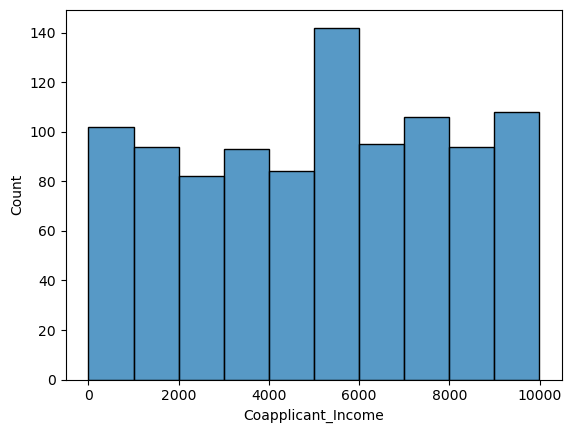

In [98]:
#analyze income
sns.histplot(
    data = df ,
    x = "Coapplicant_Income",
    bins = 10
)


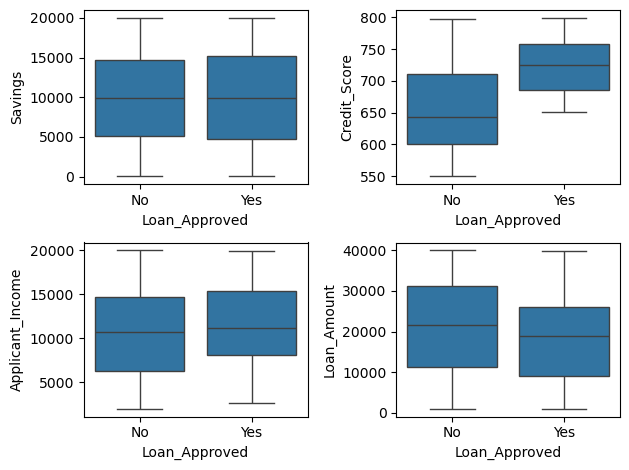

In [106]:
fig , axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0] ,data=df, x="Loan_Approved",y = "Savings")
sns.boxplot(ax = axes[0,1] ,data=df, x="Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0] ,data=df, x="Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[1,1] ,data=df, x="Loan_Approved",y = "Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

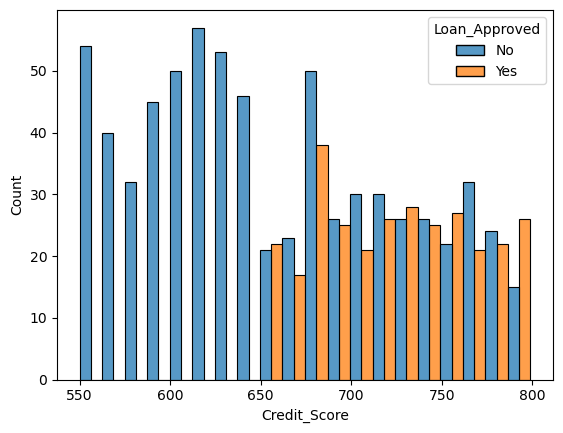

In [110]:
#credit score and loan_approved
sns.histplot(
    data =df , 
    x = "Credit_Score", 
    hue = "Loan_Approved" , 
    bins =20 ,
    multiple = "dodge"
)


In [112]:
df = df.drop("Applicant_ID" , axis =1)


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [122]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] =  le.fit_transform(df["Loan_Approved"])

In [124]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [150]:
cols = ["Employment_Status" ,"Marital_Status","Loan_Purpose" ,"Property_Area","Education_Level","Gender","Employer_Category"]
ohe = OneHotEncoder(drop = "first" , sparse_output =False , handle_unknown = "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded , columns=ohe.get_feature_names_out(cols), index = df.index)


In [154]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Education_Level_1', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [160]:
df = pd.concat([df.drop(columns= cols) ,encoded_df],axis=1)

In [165]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Loan_Approved                    1000 non-null   int32  
 12  Employment_Status_Sal

# correlation

In [175]:
num_cols = df.select_dtypes(include ="number")
corr_matrix = num_cols.corr()

<Axes: >

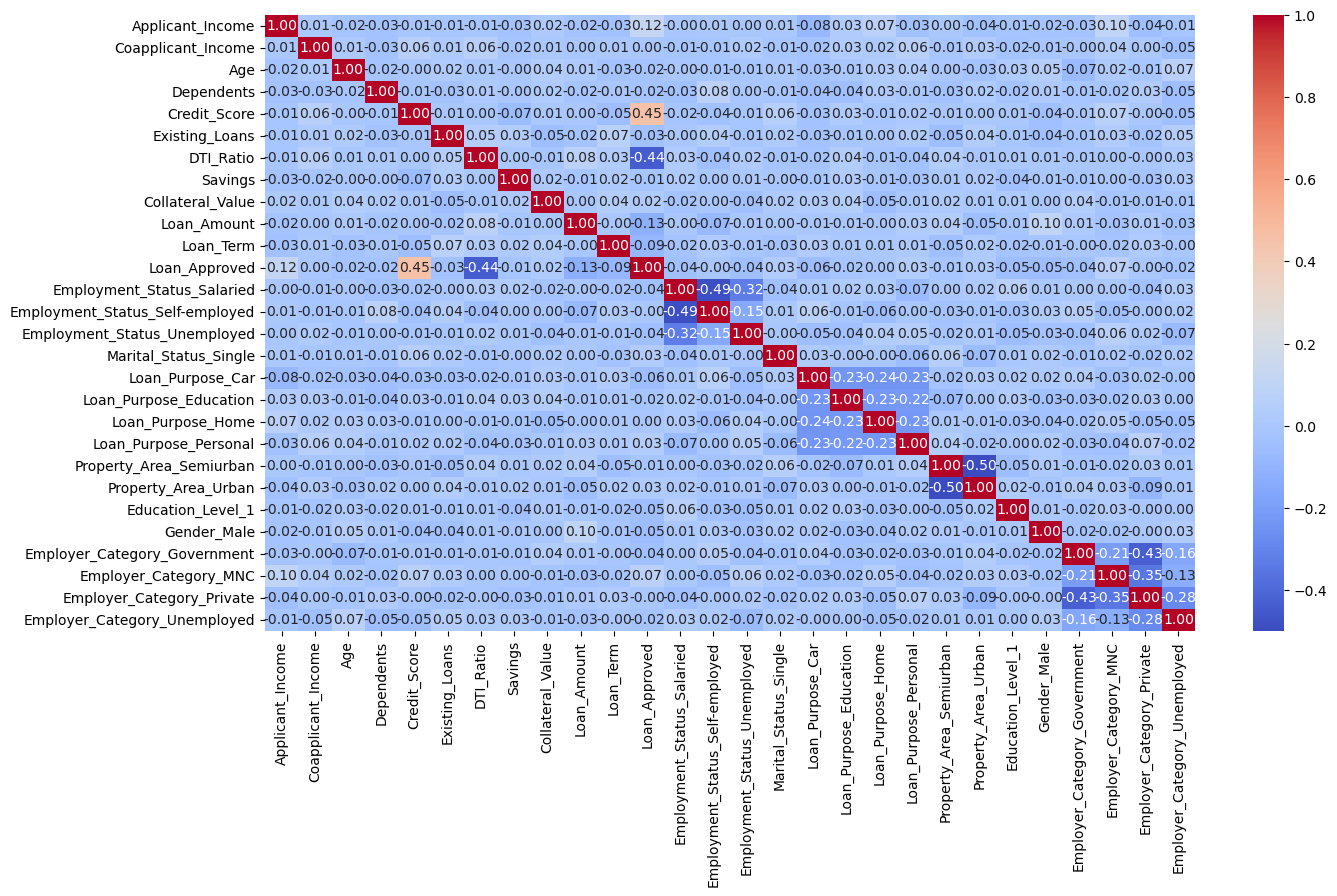

In [201]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot = True ,
    cmap = "coolwarm",
    fmt = ".2f"
)


# Train-Test + featuring

In [204]:
X = df.drop("Loan_Approved" , axis =1)
y  = df["Loan_Approved"]

In [213]:
X_train ,X_test , y_train , y_test  = train_test_split(X , y , test_size = 0.2,random_state =42)

In [215]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_1,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [222]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# model Training and Evaluation

In [241]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , recall_score , precision_score , f1_score , accuracy_score
log_model  = LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred = log_model.predict(X_test_scaled)
#evaluation
print("LOGIC REGREESION MODEL")
print("precision : ", precision_score(y_test , y_pred))
print("f1 score : ", f1_score(y_test , y_pred))
print("accuracy : ", accuracy_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("recall : ", recall_score(y_test , y_pred))

LOGIC REGREESION MODEL
precision :  0.8518518518518519
f1 score :  0.8
accuracy :  0.885
confusion_matrix :  [[131   8]
 [ 15  46]]
recall :  0.7540983606557377


In [249]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred = knn_model.predict(X_test_scaled)
#evaluation
print("KNN model")
print("precision : ", precision_score(y_test , y_pred))
print("f1 score : ", f1_score(y_test , y_pred))
print("accuracy : ", accuracy_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("recall : ", recall_score(y_test , y_pred))

KNN model
precision :  0.6086956521739131
f1 score :  0.5233644859813084
accuracy :  0.745
confusion_matrix :  [[121  18]
 [ 33  28]]
recall :  0.45901639344262296


In [251]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)
y_pred = nb_model.predict(X_test_scaled)
#evaluation
print("NB model")
print("precision : ", precision_score(y_test , y_pred))
print("f1 score : ", f1_score(y_test , y_pred))
print("accuracy : ", accuracy_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("recall : ", recall_score(y_test , y_pred))

NB model
precision :  0.7777777777777778
f1 score :  0.7304347826086957
accuracy :  0.845
confusion_matrix :  [[127  12]
 [ 19  42]]
recall :  0.6885245901639344


# Decision tree with pre-pruning